# **NOTEBOOK CLASE 1 UNIDAD 6 - FUNDAMENTOS DE CIENCIA DE DATOS**

## ***Ajustes y modelos: Regresión Lineal***

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Datos
datos = pd.DataFrame({ 'id' : [1,2,3,4,5,6,7,8,9,10],
'sup_m2' : [45, 60, 75, 90, 110, 130, 55, 80, 100, 120],
'precio_usd' : [82000, 97500, 128000, 155000, 190000, 225000, 97000, 124000, 185000, 210000]})
datos.head()

,id,sup_m2,precio_usd
0,1,45,82000
1,2,60,97500
2,3,75,128000
3,4,90,155000
4,5,110,190000


In [ ]:
# Ajustamos modelo
modelo_deptos = smf.ols(formula = 'precio_usd ~ sup_m2', data = datos).fit()
print(modelo_deptos.summary())

                            OLS Regression Results                            
Dep. Variable:             precio_usd   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     450.1
Date:                Fri, 15 May 2026   Prob (F-statistic):           2.56e-08
Time:                        21:59:10   Log-Likelihood:                -101.82
No. Observations:                  10   AIC:                             207.6
Df Residuals:                       8   BIC:                             208.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3676.4706   7559.092     -0.486      0.6

**Ecuación de la recta ajustada:**

$\hat{y} = -3676.5 + 1769.1x$

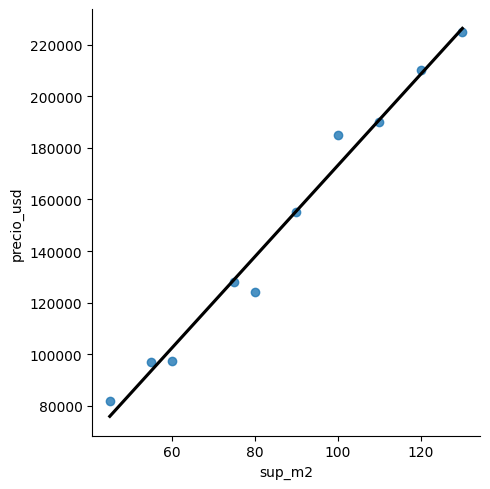

In [ ]:
sns.lmplot(x = 'sup_m2', y = 'precio_usd', ci = False, data = datos, line_kws = {'color' : 'black'})

## DATASET PENGUINS

In [ ]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Ajustar un modelo de regresión lineal simple que permita predecir la masa corporal de un pingüino de esta región en función de la longitud de su aleta.

In [ ]:
# Modelo body_mass vs. flipper_length
modelo1 = smf.ols(formula = 'body_mass_g ~ flipper_length_mm', data = penguins).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Fri, 15 May 2026   Prob (F-statistic):          4.37e-107
Time:                        22:40:42   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.81

**Ecuación de la recta ajustada:**

$\hat{y} = -5780.8 + 49.7x$

$R^2 = 0.759$

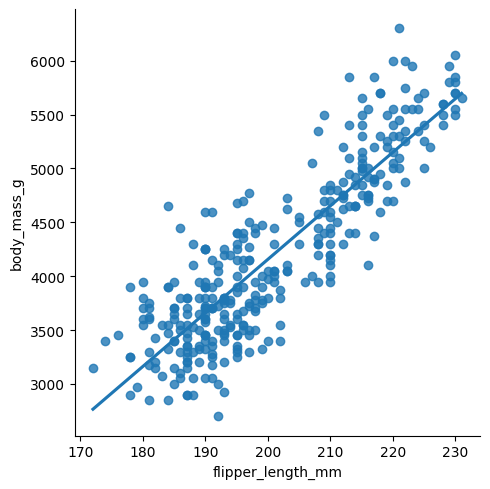

In [ ]:
sns.lmplot(x = 'flipper_length_mm', y = 'body_mass_g', ci = False, data = penguins)

## Utilizar el modelo ajustado para predecir la masa corporal de un pingüino con una longitud de aleta de 207 mm.

$\hat{y} = -5780.8 + 49.7x$

In [ ]:
-5780.8+49.7*207 # Peso predicho por el modelo para el pingüino (en g)

4507.100000000001

## Utilizar el modelo ajustado para predecir la masa corporal de un pingüino hembra con una longitud de aleta de 207 mm.

In [ ]:
-5780.8+49.7*207 # Peso predicho por el modelo para el pingüino HEMBRA (en g)

4507.100000000001

# CREACIÓN DE VARIABLES DUMMY

In [ ]:
# Creación de male_dummy
penguins['male_dummy'] = penguins['sex'].apply(lambda x: 1 if x == 'Male' else 0)

In [ ]:
modelo2 = smf.ols(formula = 'body_mass_g ~ flipper_length_mm + male_dummy', data = penguins).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     691.0
Date:                Fri, 15 May 2026   Prob (F-statistic):          2.53e-120
Time:                        22:56:58   Log-Likelihood:                -2493.9
No. Observations:                 342   AIC:                             4994.
Df Residuals:                     339   BIC:                             5005.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5327.2009    281.73